# Исследование сервиса аренды самокатов GoFast


Получены данные сервиса аренды самокатов GoFast - набор данных содержит информацию о пользователях из нескольких городов, их поездках и подписках. 

Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. Сервисом можно пользоваться без подписки и с подпиской Ultra.

**Данные состоят из трёх датасетов:** 
- информация о пользователях: 
  - уникальный идентификатор пользователя;
  - имя , возраст и город проживания пользователя;
  - тип подписки;
- информация о поездках: 
  - уникальный идентификатор пользователя;
  - расстояние, которое пользователь проехал в текущей сессии (в метрах);
  - продолжительность сессии (в минутах);
  - дата совершения поездки;
- информация о подписках:
  - тип подписки;
  - стоимость одной минуты поездки по данной подписке;
  - стоимость начала поездки;
  - стоимость ежемесячного платежа
  
**Условия пользования сервисом:**
* без подписки
  * абонентская плата отсутствует;
  * стоимость одной минуты поездки — 8 рублей;
  * стоимость старта (начала поездки) — 50 рублей;
* с подпиской Ultra
  * абонентская плата — 199 рублей в месяц;
  * стоимость одной минуты поездки — 6 рублей;
  * стоимость старта — бесплатно.

Необходимо изучить данные и проверить некоторые гипотезы, которые могут помочь бизнесу вырасти и увеличить количество пользователей с подпиской.

Изучим полученные данные, проведём предобработку, после чего проведём исследовательский анализ и перейдём к проверке гипотез.

--- 

## Загрузка данных

Импортируем необходимые библиотеки:

In [1]:
pip install missingno -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats as st
from math import sqrt
import missingno as msno
import seaborn as sns

Выберем параметры отображения данных и визуализаций:

In [3]:
sns.set_theme(style="darkgrid", palette="icefire")
pd.set_option('display.max_columns', None)
pd.options.display.float_format ='{:,.3f}'.format

Считаем данные из csv-файла с информацией **о пользователях** в датафрейм и сохраним в переменную `users`:

In [12]:
users = pd.read_csv('/datasets/users_go.csv')

Выведем первые 20 строчек датафрейма `users` на экран:

In [13]:
users.head(20)

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra
5,6,Регина,25,Краснодар,ultra
6,7,Игорь,23,Омск,ultra
7,8,Юрий,23,Краснодар,ultra
8,9,Ян,21,Пятигорск,ultra
9,10,Валерий,18,Екатеринбург,ultra


Считаем данные из csv-файла с информацией **о поездках** в датафрейм и сохраним в переменную `rides`:

In [14]:
rides = pd.read_csv('/datasets/rides_go.csv')

Выведем первые 20 строчек датафрейма `rides` на экран:

In [15]:
rides.head(20)

,user_id,distance,duration,date
0,1,"4,409.919",25.600,2021-01-01
1,1,"2,617.592",15.817,2021-01-18
2,1,754.160,6.232,2021-04-20
3,1,"2,694.783",18.511,2021-08-11
4,1,"4,028.687",26.266,2021-08-28
5,1,"2,770.891",16.650,2021-10-09
6,1,"3,039.020",14.928,2021-10-19
7,1,"2,842.118",23.117,2021-11-06
8,1,"3,412.691",15.238,2021-11-14
9,1,748.691,15.042,2021-11-22


Считаем данные из csv-файла с информацией **о подписках** в датафрейм и сохраним в переменную `subscriptions`:

In [16]:
subscriptions = pd.read_csv('/datasets/subscriptions_go.csv')

Выведем датафрейм `subscriptions` на экран:

In [17]:
subscriptions.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


Изучим структуру и полноту полученных датафреймов:

- `users`

In [18]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


<AxesSubplot:>

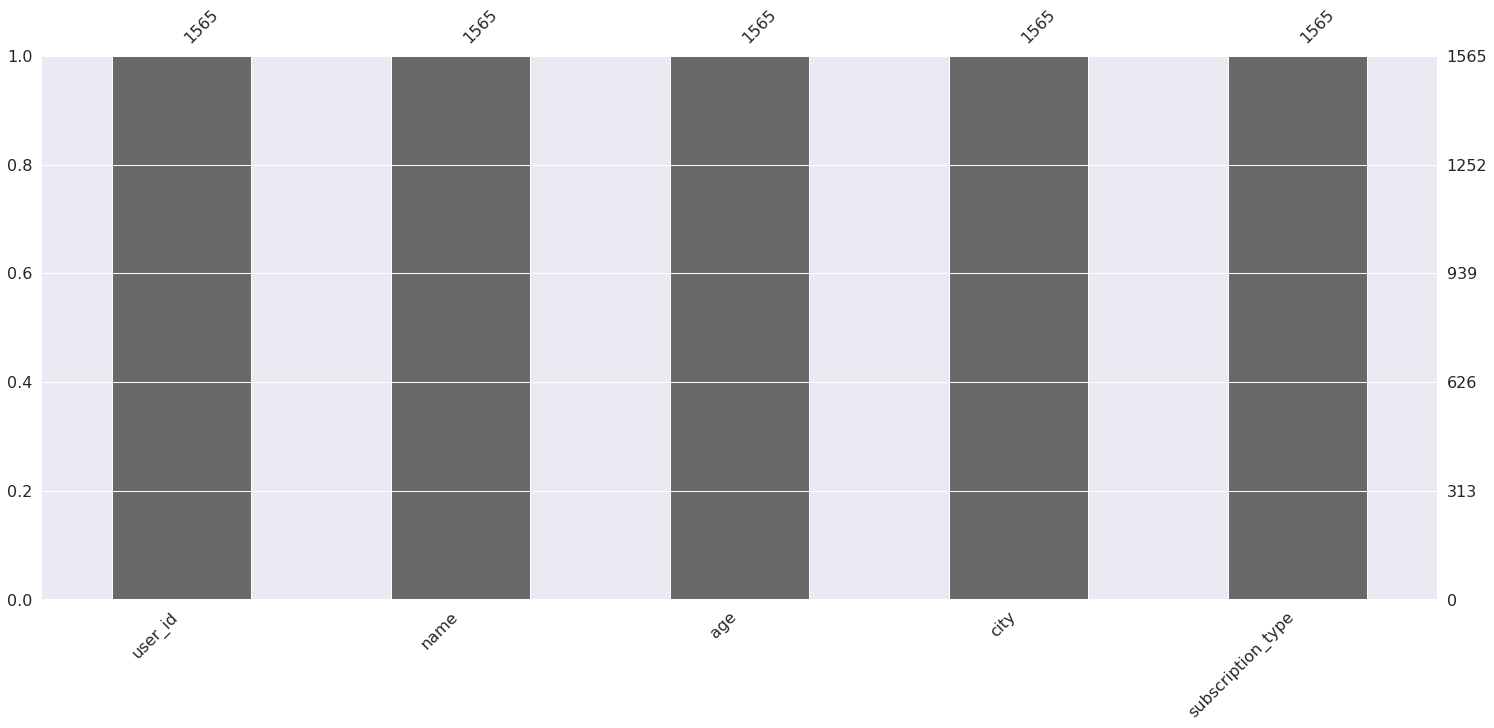

In [19]:
msno.bar(users)

---
- `rides`

In [20]:
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


<AxesSubplot:>

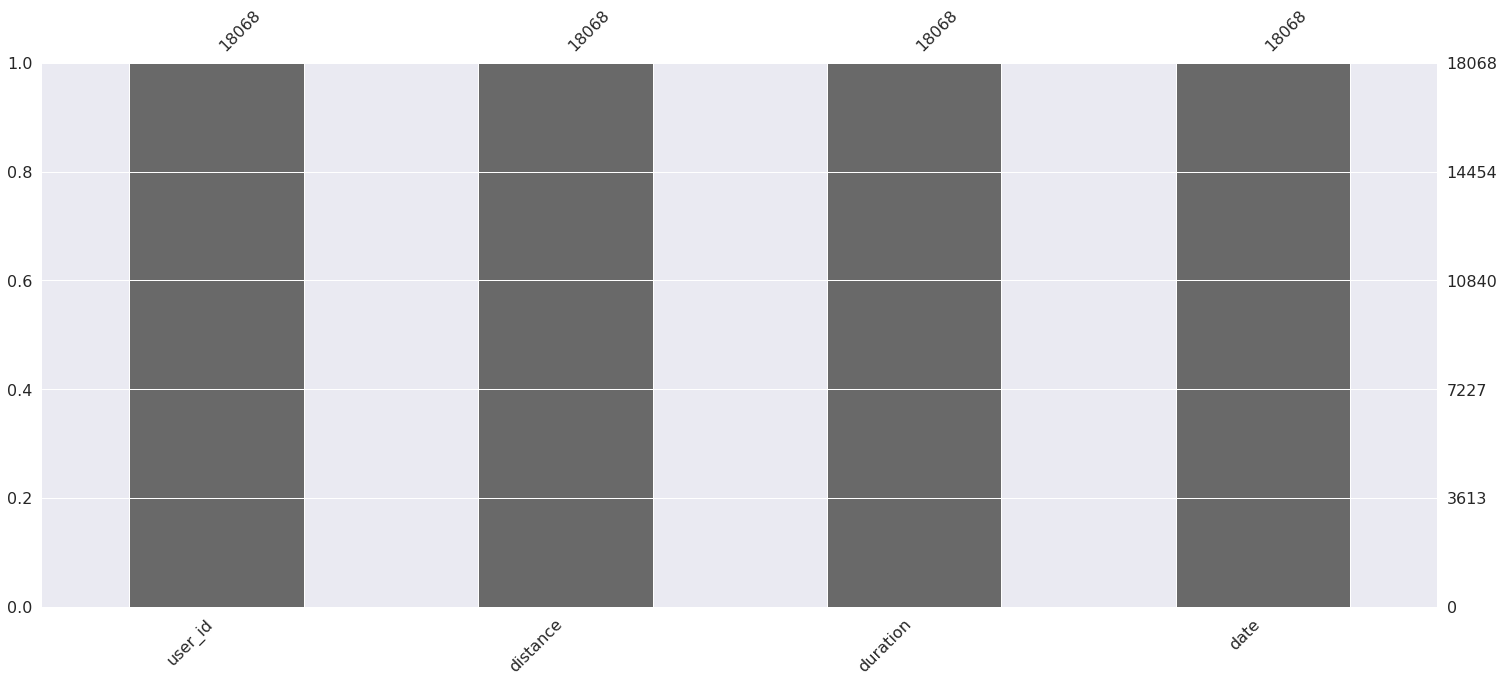

In [21]:
msno.bar(rides)

--- 
- `subscriptions`

In [22]:
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


<AxesSubplot:>

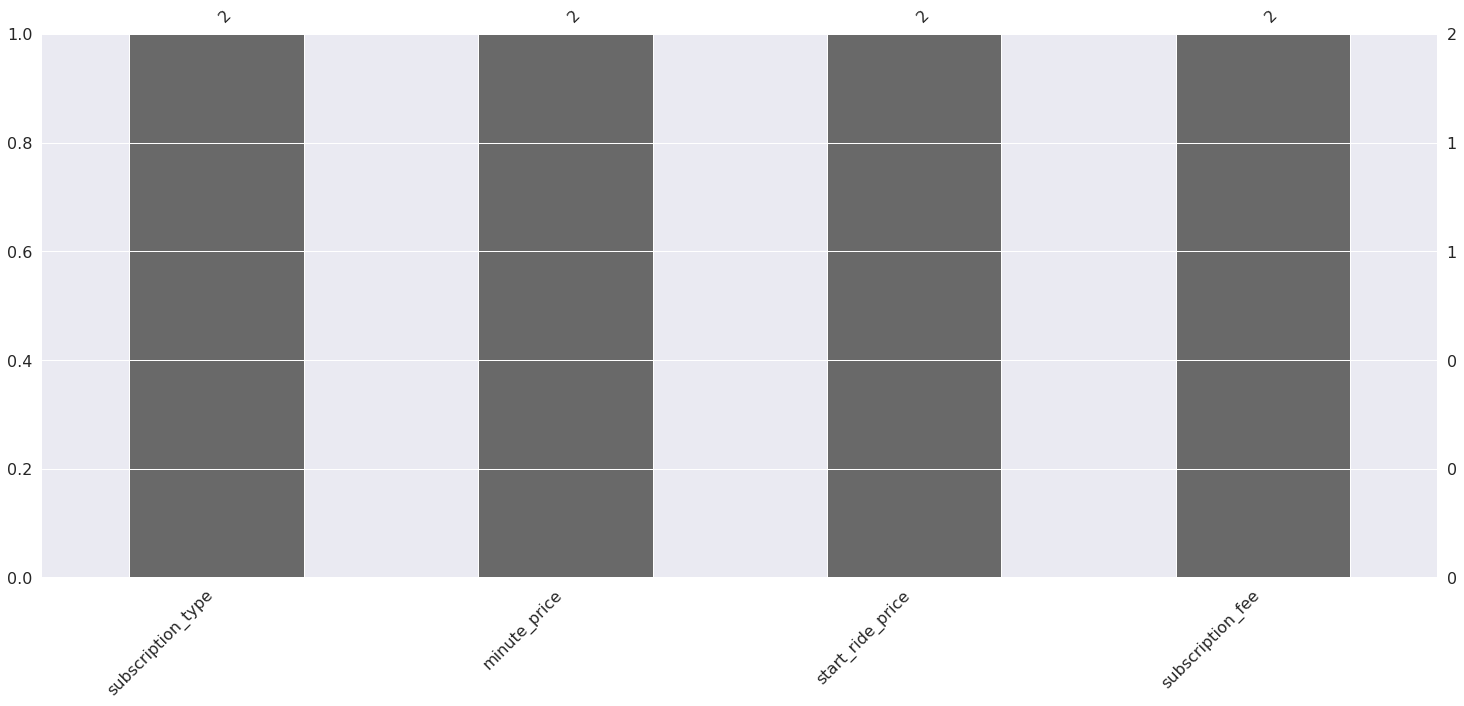

In [23]:
msno.bar(subscriptions)

---
**Вывод**

Полученные датафреймы содержат следующие данные:

- `users` - информация о пользователях из нескольких городов;
- `rides` - информация об их поездках;
- `subscriptions` - информация о подписках

Предварительно можно утверждать, что данных достаточно для проведения анализа. 
В датасетах отсутствуют пропущенные значения, столбцы именованы корректно. При этом у некоторых колонок неподходящий для анализа тип данных, а также в датафреймах могут присутствовать дубликаты.

Необходима предобработка данных.

---

## Предобработка данных

### Тип данных

Определим столбцы, где можно заменить тип данных.

Столбец `date` в датафрейме `rides` приведём к типу  **datetime**:

In [24]:
rides['date'] = pd.to_datetime(rides['date'], format = '%Y-%m-%d')

Проверим результат:

In [25]:
rides.dtypes

user_id              int64
distance           float64
duration           float64
date        datetime64[ns]
dtype: object

### Добавление столбцов

Добавим в датафрейм `rides` новый столбец с номером месяца на основе столбца `date`:

In [26]:
rides['month'] = rides['date'].dt.month

Проверим результат:

In [27]:
rides.head()

,user_id,distance,duration,date,month
0,1,"4,409.919",25.600,2021-01-01,1
1,1,"2,617.592",15.817,2021-01-18,1
2,1,754.160,6.232,2021-04-20,4
3,1,"2,694.783",18.511,2021-08-11,8
4,1,"4,028.687",26.266,2021-08-28,8


In [28]:
rides['month'].value_counts()

1     1585
5     1560
6     1553
3     1544
7     1529
12    1527
8     1518
9     1517
4     1506
10    1475
11    1418
2     1336
Name: month, dtype: int64

Данные о поездках представлены за 12 месяцев, количество поездок по месяцам относительно одинаковое.

### Проверка пропусков

Гистограммы `msno` показали отсутствие пропущенных значений, данные в датафреймах представлены полностью, дополнительная проверка пропусков не требуется.

### Проверка дубликатов

Проверим наличие явных дубликатов в датафрейме `users`:

In [29]:
users.duplicated().sum()

31

Выведем дубликаты на экран и изучим подробнее:

In [30]:
users[users.duplicated(keep=False)]

,user_id,name,age,city,subscription_type
15,16,Амалия,27,Краснодар,ultra
42,43,Стефания,22,Омск,ultra
46,47,Юрий,28,Тюмень,ultra
71,72,Никита,25,Москва,ultra
107,108,Влада,29,Тюмень,ultra
...,...,...,...,...,...
1560,829,Федор,29,Пятигорск,free
1561,809,Юрий,26,Сочи,free
1562,307,Ясмина,19,Краснодар,ultra
1563,47,Юрий,28,Тюмень,ultra


Строки полностью дублируются, их удаление не приведёт к потере данных.

Удалим явные дубликаты из датафрейма: 

In [31]:
users = users.drop_duplicates()

Проверим результат: 

In [32]:
users.duplicated().sum()

0

Явные дубликаты удалены.

---

Проверим наличие явных дубликатов в датафрейме `rides`

In [33]:
rides.duplicated().sum()

0

Явные дубликаты отсутствуют.

---

Проверим наличие явных дубликатов в датафрейме `subscriptions`

In [34]:
subscriptions.duplicated().sum()

0

Явные дубликаты отсутствуют.

### Неявные дубликаты

Изучим столбцы `age` и `city` датафрейма `users` на наличие неявных дубликатов: 

In [35]:
users['age'].unique()

array([22, 31, 20, 26, 28, 25, 23, 21, 18, 27, 24, 29, 32, 14, 19, 30, 17,
       12, 35, 33, 13, 15, 37, 16, 34, 38, 36, 39, 43])

In [36]:
users['city'].unique()

array(['Тюмень', 'Омск', 'Москва', 'Ростов-на-Дону', 'Краснодар',
       'Пятигорск', 'Екатеринбург', 'Сочи'], dtype=object)

Неявные дубликаты не обнаружены.

### Аномалии в данных

Изучим столбцы `distance` и `duration` датафрейма `rides` на наличие аномалий и выбросов с помощью метода `describe()`:

In [37]:
rides['distance'].describe()

count   18,068.000
mean     3,070.660
std      1,116.831
min          0.856
25%      2,543.226
50%      3,133.610
75%      3,776.223
max      7,211.008
Name: distance, dtype: float64

In [38]:
rides['duration'].describe()

count   18,068.000
mean        17.805
std          6.091
min          0.500
25%         13.598
50%         17.678
75%         21.725
max         40.824
Name: duration, dtype: float64

Данные в столбцах распределены корректно, отсутствуют отрицательные значения и аномальные выбросы.

---

**Вывод**

Для корректного проведения исследования выполнена предобработка данных:

- Проверены и при необходимости преобразованы типы данных;
- Проверены пропуски в датафреймах;
- Изучены и обработаны дубликаты в датафреймах, в том числе и неявные;
- Для дальнейшего анализа добавлен столбец с номером месяца поездки;
- Данные проверены на наличие выбросов и аномалий

---
## Исследовательский анализ данных

### Частота встречаемости городов 

Изучим частоту встречаемости городов в датафрейме `users`:

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64

Text(0, 0.5, 'Город')

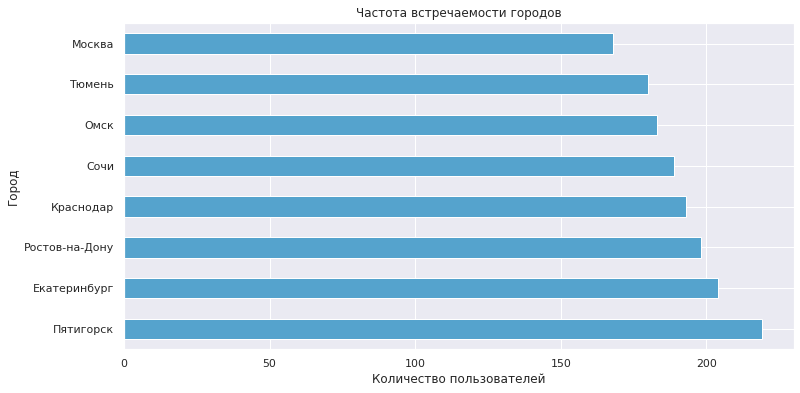

In [39]:
grouped_city = users['city'].value_counts()
display(grouped_city) 

grouped_city.plot(kind='barh', figsize=(12,6), title='Частота встречаемости городов')
plt.xlabel("Количество пользователей")
plt.ylabel("Город")

**Вывод**

Наиболее часто в выборке встречается город Пятигорск - 219 пользователей, реже всего встречается город Москва - 168 пользователей.

### Соотношение пользователей с подпиской и без

Изучим количество пользователей с подпиской и без подписки в датафрейме `users`:

In [40]:
grouped_subs = users.pivot_table(index = 'subscription_type', values = 'user_id', aggfunc='count')
display(grouped_subs)

,user_id
subscription_type,
free,835
ultra,699


Найдём долю каждой категории пользователей от общего числа клиентов: 

In [ ]:
grouped_subs['quota'] = grouped_subs['user_id'] / users['user_id'].count()
display(grouped_subs)

grouped_subs['quota'].plot(kind='pie', figsize=(12,6), autopct='%.2f', textprops=dict(color='black', fontsize=14), \
                           title='Соотношение пользователей с подпиской и без подписки')
plt.axis('off');

**Вывод**

Распределение пользователей в выборке практически равномерное: 54% клиентов без платной подписки и 46% клиентов имеют платную подписку

### Возраст пользователей

Изучим возраст пользователей в датафрейме `users`.

count   1,534.000
mean       24.904
std         4.572
min        12.000
25%        22.000
50%        25.000
75%        28.000
max        43.000
Name: age, dtype: float64

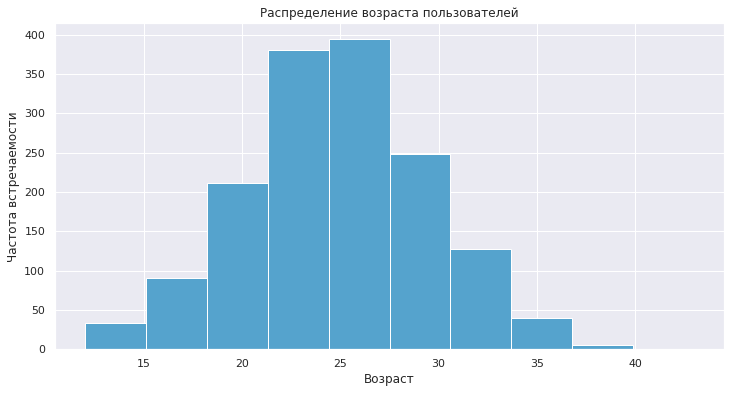

In [42]:
users['age'].plot.hist(figsize=(12,6), title='Распределение возраста пользователей')
plt.xlabel("Возраст")
plt.ylabel("Частота встречаемости")

users['age'].describe()

**Вывод**

Получено нормальное распределение:
- самой многочисленной категорией в выборке являются пользователи от 20 до 30 лет. 
- самой малочисленной - клиенты в возрасте до 15 лет и от 35 лет.

### Расстояние, которое пользователь преодолел за одну поездку

Изучим расстояние, которое пользователь преодолел за одну поездку, с помощью столбца `distance` датафрейма `rides`.

count   18,068.000
mean     3,070.660
std      1,116.831
min          0.856
25%      2,543.226
50%      3,133.610
75%      3,776.223
max      7,211.008
Name: distance, dtype: float64

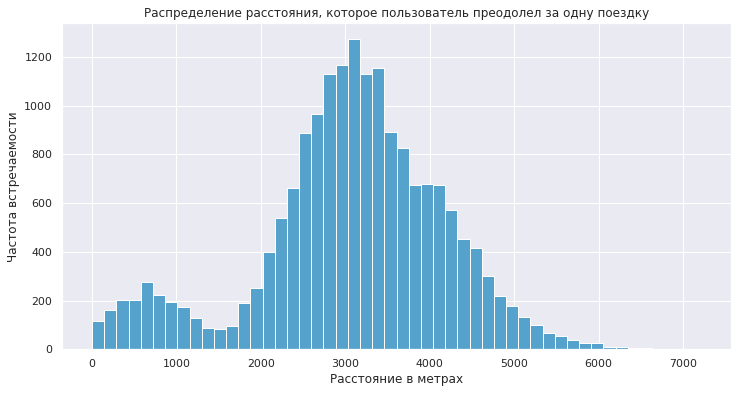

In [43]:
rides['distance'].plot.hist(figsize=(12,6), bins=50, \
                            title='Распределение расстояния, которое пользователь преодолел за одну поездку')

plt.xlabel("Расстояние в метрах")
plt.ylabel("Частота встречаемости")

rides['distance'].describe()

**Вывод**

Чаще всего пользователи берут самокат на средние расстояния от 2 до 4 км, реже всего - на длинные дистанции от 5 км.

Также на графике заметен небольшой пик поездок с расстоянием до 1км.

### Продолжительность поездок

Изучим продолжительность поездок пользователей с помощью столбца `duration` датафрейма `rides`.

count   18,068.000
mean     3,070.660
std      1,116.831
min          0.856
25%      2,543.226
50%      3,133.610
75%      3,776.223
max      7,211.008
Name: distance, dtype: float64

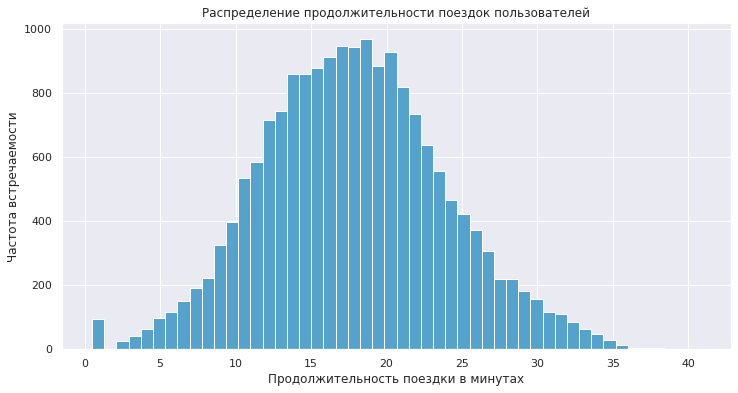

In [44]:
rides['duration'].plot.hist(figsize=(12,6), bins=50, title='Распределение продолжительности поездок пользователей')

plt.xlabel("Продолжительность поездки в минутах")
plt.ylabel("Частота встречаемости")

rides['distance'].describe()

Рассмотрим подробнее поездки, длительность которых составила меньше 1 минуты:

In [45]:
rides[rides['duration'] < 1]

,user_id,distance,duration,date,month
6531,701,"4,196.445",0.500,2021-08-31,8
6570,704,"4,830.824",0.500,2021-10-14,10
6680,712,"4,684.004",0.500,2021-03-04,3
6695,713,"5,215.643",0.500,2021-02-25,2
6768,718,"5,197.437",0.500,2021-02-11,2
...,...,...,...,...,...
17004,1460,"5,531.336",0.500,2021-01-19,1
17242,1477,"6,724.933",0.500,2021-01-12,1
17314,1483,"4,445.481",0.500,2021-03-06,3
17505,1496,"5,722.552",0.500,2021-02-14,2


Все поездки длились ровно 0.500 минут, похоже, что какая-то из автоматических проверок отменила поездку. 

Можно предположить, что это пользователи без платной подписки и сервис не смог списать стоимость старта поездки, в следствии чего поездка была завершена.

**Вывод**

Самая частая продолжительность поездки - от 10 до 25 минут, что коррелируется с самым частым расстоянием поездок.

Наименее частые поездки длятся до 5 минут и превышают 30 минут.

Дополнительно был выявлен и исследован небольшой пик при 0, в который вошли отменённые поездки. 

## Объединение данных

### Объединение датафреймов

Для объединения трёх датафреймов сначала объединим таблицы `users` и `rides` по столбцу `user_id` и запишем в переменную `users_rides`.
После чего полученный датафрейм объединим с таблицей `subscriptions` по столбцу `subscription_type`.

Для объединения воспользуемся методом `merge()` с режимом `left`.

Сначала убедимся, что тип столбцов, по которым будет проходить объединение таблиц, совпадает:

In [46]:
users.dtypes

user_id               int64
name                 object
age                   int64
city                 object
subscription_type    object
dtype: object

In [47]:
rides.dtypes

user_id              int64
distance           float64
duration           float64
date        datetime64[ns]
month                int64
dtype: object

In [48]:
subscriptions.dtypes

subscription_type    object
minute_price          int64
start_ride_price      int64
subscription_fee      int64
dtype: object

Столбец `user_id` имеет тип **int64** в обеих таблицах, а столбец `subscription_type` - тип **object**. 

Можем переходить к объединению датафреймов, соединим `rides` и `users` по `user_id`:

In [49]:
users_rides = rides.merge(users, how='left', on='user_id')

Выведем на экран первые строки полученного датафрейма `users_rides` и общую информацию о таблице:

In [50]:
users_rides.head(20)

,user_id,distance,duration,date,month,name,age,city,subscription_type
0,1,"4,409.919",25.600,2021-01-01,1,Кира,22,Тюмень,ultra
1,1,"2,617.592",15.817,2021-01-18,1,Кира,22,Тюмень,ultra
2,1,754.160,6.232,2021-04-20,4,Кира,22,Тюмень,ultra
3,1,"2,694.783",18.511,2021-08-11,8,Кира,22,Тюмень,ultra
4,1,"4,028.687",26.266,2021-08-28,8,Кира,22,Тюмень,ultra
5,1,"2,770.891",16.650,2021-10-09,10,Кира,22,Тюмень,ultra
6,1,"3,039.020",14.928,2021-10-19,10,Кира,22,Тюмень,ultra
7,1,"2,842.118",23.117,2021-11-06,11,Кира,22,Тюмень,ultra
8,1,"3,412.691",15.238,2021-11-14,11,Кира,22,Тюмень,ultra
9,1,748.691,15.042,2021-11-22,11,Кира,22,Тюмень,ultra


In [51]:
users_rides.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   distance           18068 non-null  float64       
 2   duration           18068 non-null  float64       
 3   date               18068 non-null  datetime64[ns]
 4   month              18068 non-null  int64         
 5   name               18068 non-null  object        
 6   age                18068 non-null  int64         
 7   city               18068 non-null  object        
 8   subscription_type  18068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 1.4+ MB


В полученный датафрейм попали 18068 строк таблицы `rides`, объединение прошло корректно.

Далее объединим таблицы `users_rides` и `subscriptions` по столбцу `subscription_type`:

In [52]:
full = users_rides.merge(subscriptions, how='left', on='subscription_type')

Выведем на экран первые строки полученного датафрейма `full` и общую информацию о таблице:

In [53]:
full.head(20)

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,"4,409.919",25.600,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199
1,1,"2,617.592",15.817,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199
2,1,754.160,6.232,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199
3,1,"2,694.783",18.511,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199
4,1,"4,028.687",26.266,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199
5,1,"2,770.891",16.650,2021-10-09,10,Кира,22,Тюмень,ultra,6,0,199
6,1,"3,039.020",14.928,2021-10-19,10,Кира,22,Тюмень,ultra,6,0,199
7,1,"2,842.118",23.117,2021-11-06,11,Кира,22,Тюмень,ultra,6,0,199
8,1,"3,412.691",15.238,2021-11-14,11,Кира,22,Тюмень,ultra,6,0,199
9,1,748.691,15.042,2021-11-22,11,Кира,22,Тюмень,ultra,6,0,199


In [54]:
full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   distance           18068 non-null  float64       
 2   duration           18068 non-null  float64       
 3   date               18068 non-null  datetime64[ns]
 4   month              18068 non-null  int64         
 5   name               18068 non-null  object        
 6   age                18068 non-null  int64         
 7   city               18068 non-null  object        
 8   subscription_type  18068 non-null  object        
 9   minute_price       18068 non-null  int64         
 10  start_ride_price   18068 non-null  int64         
 11  subscription_fee   18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 1.8+ MB


В итоговый датафрейм `full` попали все 18068 строк самой большой таблицы `rides`, объединение прошло корректно, данные не потеряны.

### Создание датафреймов

Из полученной таблицы `full` сделаем два дополнительных датафрейма: 
- `free` - с данными о пользователях без подписки;
- `ultra` - с данными о пользователях с подпиской

In [55]:
free = full[full['subscription_type'] == 'free']

Выведем на экран первые строки датафрейма и общую информацию:

In [56]:
free.head(20)

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
6500,700,"2,515.691",14.944,2021-01-02,1,Айдар,22,Омск,free,8,50,0
6501,700,846.933,16.235,2021-02-01,2,Айдар,22,Омск,free,8,50,0
6502,700,"4,004.434",20.017,2021-02-04,2,Айдар,22,Омск,free,8,50,0
6503,700,"1,205.911",9.783,2021-02-10,2,Айдар,22,Омск,free,8,50,0
6504,700,"3,047.379",17.428,2021-02-14,2,Айдар,22,Омск,free,8,50,0
6505,700,"4,342.002",22.368,2021-02-23,2,Айдар,22,Омск,free,8,50,0
6506,700,"3,798.335",18.244,2021-03-03,3,Айдар,22,Омск,free,8,50,0
6507,700,"2,984.551",15.425,2021-04-09,4,Айдар,22,Омск,free,8,50,0
6508,700,"3,360.107",16.765,2021-06-12,6,Айдар,22,Омск,free,8,50,0
6509,700,"2,567.544",11.312,2021-06-23,6,Айдар,22,Омск,free,8,50,0


In [57]:
free.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11568 entries, 6500 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            11568 non-null  int64         
 1   distance           11568 non-null  float64       
 2   duration           11568 non-null  float64       
 3   date               11568 non-null  datetime64[ns]
 4   month              11568 non-null  int64         
 5   name               11568 non-null  object        
 6   age                11568 non-null  int64         
 7   city               11568 non-null  object        
 8   subscription_type  11568 non-null  object        
 9   minute_price       11568 non-null  int64         
 10  start_ride_price   11568 non-null  int64         
 11  subscription_fee   11568 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 1.1+ MB


Полученный датафрейм выглядит корректно, создаём таблицу `ultra`:

In [58]:
ultra = full[full['subscription_type'] == 'ultra']

Выведем на экран первые строки датафрейма и общую информацию:

In [59]:
ultra.head(20)

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,"4,409.919",25.600,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199
1,1,"2,617.592",15.817,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199
2,1,754.160,6.232,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199
3,1,"2,694.783",18.511,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199
4,1,"4,028.687",26.266,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199
5,1,"2,770.891",16.650,2021-10-09,10,Кира,22,Тюмень,ultra,6,0,199
6,1,"3,039.020",14.928,2021-10-19,10,Кира,22,Тюмень,ultra,6,0,199
7,1,"2,842.118",23.117,2021-11-06,11,Кира,22,Тюмень,ultra,6,0,199
8,1,"3,412.691",15.238,2021-11-14,11,Кира,22,Тюмень,ultra,6,0,199
9,1,748.691,15.042,2021-11-22,11,Кира,22,Тюмень,ultra,6,0,199


In [60]:
ultra.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6500 entries, 0 to 6499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            6500 non-null   int64         
 1   distance           6500 non-null   float64       
 2   duration           6500 non-null   float64       
 3   date               6500 non-null   datetime64[ns]
 4   month              6500 non-null   int64         
 5   name               6500 non-null   object        
 6   age                6500 non-null   int64         
 7   city               6500 non-null   object        
 8   subscription_type  6500 non-null   object        
 9   minute_price       6500 non-null   int64         
 10  start_ride_price   6500 non-null   int64         
 11  subscription_fee   6500 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 660.2+ KB


Датафреймы созданы корректно, в каждом собраны данные одной из категорий пользователей: с подпиской и без подписки.

Количество поездок пользователей без подписки почти в два раза превышает количество поездок пользователей с подпиской.

#### Визуализация данных

##### Расстояние поездок

Визуализируем информацию о расстоянии поездок для пользователей обеих категорий.

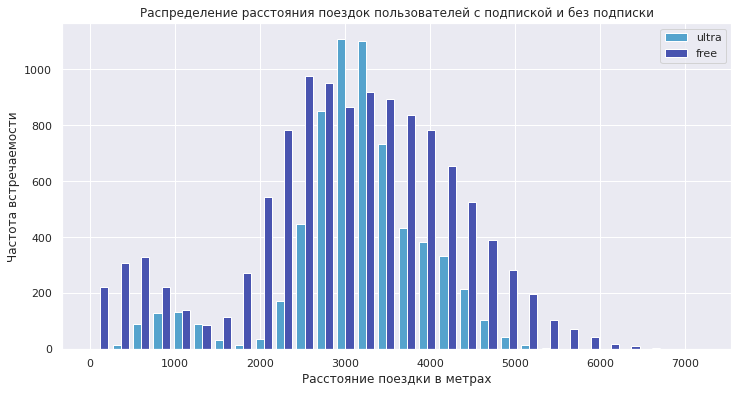

In [61]:
plt.figure(figsize=(12,6))
plt.hist([ultra['distance'], free['distance']], label=['ultra', 'free'], bins=30)
plt.legend(loc='upper right')
plt.title('Распределение расстояния поездок пользователей с подпиской и без подписки')
plt.xlabel("Расстояние поездки в метрах")
plt.ylabel("Частота встречаемости")
plt.show()

**Вывод**

Получены нормальные распределения расстояния поездок пользователей с подпиской и без.

График показывает, что среди пользователей с подпиской преобладает расстояние поездки в 3км, а среди пользователей без подписки - 2.5км.

Также можно отметить, что пользователи без подписки чаще ездят на длительные расстояния от 5км и на короткие расстояния до 1км.

---

##### Длительность поездок

Визуализируем информацию о длительности поездок для пользователей обеих категорий.

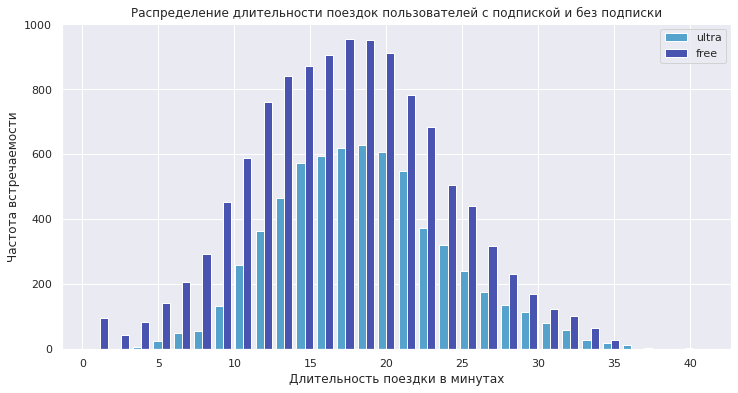

In [62]:
plt.figure(figsize=(12,6))
plt.hist([ultra['duration'], free['duration']], label=['ultra', 'free'], bins=30)
plt.title('Распределение длительности поездок пользователей с подпиской и без подписки')
plt.legend(loc='upper right')
plt.xlabel("Длительность поездки в минутах")
plt.ylabel("Частота встречаемости")
plt.show()

**Вывод**

Получены нормальные распределения длительности поездок пользователей с подпиской и без.

График показывает, что среди пользователей с подпиской преобладает длительность поездки от 13 до 18 минут, а среди пользователей без подписки - от 15 до 20 минут.

Дополнительно подтверждается предположение о том, что поездки, продолжительностью до 1 минуты отменены по причине неуспеха оплаты старта поездки. График показывает, что в данный пик вошли только пользователи без подписки.

---

**Вывод**

Для дальнейшей работы с данными исходные датафреймы  `users`, `rides` и `subscriptions` были объединенины в общую таблицу `full`.

После чего `full` была разделена на два дополнительных датафрейма `free` и `ultra`, содержащих данные о пользователях без подписки и пользователях с подпиской. 

Дополнительно были визуализированы данные о расстоянии и времени поездок для пользователей обеих категорий.

---

## Подсчёт выручки

### Агрегирование данных о поездках

С помощью датафрейма `full` создадим таблицу с агрегированными данными о суммарном расстоянии, количестве поездок и суммарном времени поездок для каждого пользователя за каждый месяц.

Дополнительно добавим помесячную стоимость подписки каждого пользователя, выбрав первое значение с помощью функции `first`.

Сохраним полученную таблицу в переменную `rides_grouped`:

In [63]:
rides_grouped = full.groupby(['user_id', 'month'])[['distance', 'duration', 'subscription_fee']] \
                .agg({'distance': ['sum'],'duration': ['sum', 'count'], 'subscription_fee': ['first']})

display(rides_grouped)

distance duration       subscription_fee
                     sum      sum count            first
user_id month                                           
1       1      7,027.511   41.417     2              199
        4        754.160    6.232     1              199
        8      6,723.471   44.777     2              199
        10     5,809.911   31.578     2              199
        11     7,003.499   53.397     3              199
...                  ...      ...   ...              ...
1534    6      3,409.469   24.813     2                0
        8      7,622.453   47.206     2                0
        9      4,928.174   22.560     1                0
        11    13,350.015   76.342     4                0
        12     2,371.711   15.894     1                0

[11331 rows x 4 columns]

### Агрегирование выручки

В полученный датафрейм `rides_grouped` добавим данные о помесячной выручке, которую принёс каждый пользователь. 

Для этого рассчитаем стоимость поездок в датафрейме `full` следующим образом: 
- умножим цену за минуту поездки на продолжительность поездки, округлённую вверх до ближайшего целого;
- прибавим к получившейся стоимости поездки стоимость старта поездки
  
Полученный результат запишем в столбец `revenue_rides`:

In [64]:
full['revenue_rides'] = (full['minute_price'] * full['duration'].apply(np.ceil)) \
                    + full['start_ride_price']

Проверим результат:

In [65]:
full.head(20)

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,revenue_rides
0,1,"4,409.919",25.600,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199,156.000
1,1,"2,617.592",15.817,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199,96.000
2,1,754.160,6.232,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199,42.000
3,1,"2,694.783",18.511,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199,114.000
4,1,"4,028.687",26.266,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199,162.000
5,1,"2,770.891",16.650,2021-10-09,10,Кира,22,Тюмень,ultra,6,0,199,102.000
6,1,"3,039.020",14.928,2021-10-19,10,Кира,22,Тюмень,ultra,6,0,199,90.000
7,1,"2,842.118",23.117,2021-11-06,11,Кира,22,Тюмень,ultra,6,0,199,144.000
8,1,"3,412.691",15.238,2021-11-14,11,Кира,22,Тюмень,ultra,6,0,199,96.000
9,1,748.691,15.042,2021-11-22,11,Кира,22,Тюмень,ultra,6,0,199,96.000


Агрегируем данные о стоимости поездок помесячно по каждому пользователю и добавим столбец `revenue_rides` в датафрейм `rides_grouped`:

In [66]:
rides_grouped['revenue_rides'] = full.groupby(['user_id', 'month'])['revenue_rides'].sum()
display(rides_grouped)

distance duration       subscription_fee revenue_rides
                     sum      sum count            first              
user_id month                                                         
1       1      7,027.511   41.417     2              199       252.000
        4        754.160    6.232     1              199        42.000
        8      6,723.471   44.777     2              199       276.000
        10     5,809.911   31.578     2              199       192.000
        11     7,003.499   53.397     3              199       336.000
...                  ...      ...   ...              ...           ...
1534    6      3,409.469   24.813     2                0       308.000
        8      7,622.453   47.206     2                0       484.000
        9      4,928.174   22.560     1                0       234.000
        11    13,350.015   76.342     4                0       824.000
        12     2,371.711   15.894     1                0       178.000

[11331 rows x 5 columns]

Сложим выручку от поездок пользователей из столбца `revenue_rides` и стоимость месячной подписки из столбца `subscription_fee`.

Сумму полной помесячной выручки от каждого пользователя запишем в столбец `revenue_full`:

In [67]:
rides_grouped['revenue_full'] = rides_grouped[(   'revenue_rides',      '')] + rides_grouped[('subscription_fee', 'first')]
display(rides_grouped)

distance duration       subscription_fee revenue_rides  \
                     sum      sum count            first                 
user_id month                                                            
1       1      7,027.511   41.417     2              199       252.000   
        4        754.160    6.232     1              199        42.000   
        8      6,723.471   44.777     2              199       276.000   
        10     5,809.911   31.578     2              199       192.000   
        11     7,003.499   53.397     3              199       336.000   
...                  ...      ...   ...              ...           ...   
1534    6      3,409.469   24.813     2                0       308.000   
        8      7,622.453   47.206     2                0       484.000   
        9      4,928.174   22.560     1                0       234.000   
        11    13,350.015   76.342     4                0       824.000   
        12     2,371.711   15.894     1                0       178.000   

              revenue_full  
                            
user_id month               
1       1          451.000  
        4          241.000  
        8          475.000  
        10         391.000  
        11         535.000  
...                    ...  
1534    6          308.000  
        8          484.000  
        9          234.000  
        11         824.000  
        12         178.000  

[11331 rows x 6 columns]

**Вывод**

На данном этапе исследования был получен датафрейм `rides_grouped` с агрегированными помесячно данными: 
- суммарное расстояние;
- суммарная продолжительность;
- количество поездок;
- выручка, которую принёс каждый пользователь.

---
## Проверка гипотез

### Гипотеза №1

**Условие**

Продакт-менеджеры сервиса хотят увеличить количество пользователей с подпиской. Для этого они будут проводить различные акции, но сначала нужно выяснить несколько важных моментов.

Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. Проверьте гипотезу. Используйте исходные данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.

**Решение**

Необходимо понять, тратят ли пользователи с подпиской больше времени на поездки, чем пользователи без подписки. Если да, то пользователи с подпиской могут быть «выгоднее» для компании. 

Сформулируем гипотезу: 

- $H_0$ - средние значения совокупностей "время поездки пользователей с подпиской" и "время поездки пользователей без подписки" равны;
- $H_1$ - среднее значение совокупности "время поездки пользователей с подпиской" больше среднего значения совокупности "время поездки пользователей без подписки"

Проверять гипотезу будем по выборочным средним на датафреймах `free` и `ultra`, где собраны данные о пользователях с подпиской и без.

Для проверки используем метод `t-тест`, в данном случае он уместен: 
 - генеральные совокупности не зависят друг от друга;
 - выборочные средние нормально распределены

Гистограмма 'Длительность поездок пользователей с подпиской и без подписки' показала относительно равную дисперсию для обеих категорий пользователей, поэтому параметр `equal_var` оставим в значении `True`.

Уровень статистической значимости установим в 0.05.

Параметр `alternative` укажем как `greater` для правосторонней альтернативной гипотезы.

Проверим, можно ли отвергнуть нулевую гипотезу в пользу альтернативной: 

In [68]:
alpha = .05 

results = st.ttest_ind(ultra['duration'], free['duration'], alternative='greater')

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    
print('Средняя продолжительность поездок пользователей с подпиской:', ultra['duration'].mean())
print('Средняя продолжительность поездок пользователей без подписки:', free['duration'].mean())

p-value: 1.2804098316645618e-34
Отвергаем нулевую гипотезу
Средняя продолжительность поездок пользователей с подпиской: 18.54198516280583
Средняя продолжительность поездок пользователей без подписки: 17.39090929866399


**Вывод**

Полученное значение `p-value` равно $1.2804098316645618⋅10^{-34}$, а значит, вероятность получения наблюдаемых результатов при условии, что нулевая гипотеза верна, очень мала.

Нулевая гипотеза отвергается в пользу альтернативной и можно заключить, что пользователи с подпиской действительно тратят **больше** времени на поездки, чем пользователи без подписки.

### Гипотеза №2

**Условие** 

Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? Проверьте гипотезу и сделайте выводы.

**Решение**

Сформулируем гипотезу: 

- $H_0$ - среднее значение совокупности "расстояние поездки пользователей с подпиской" равна 3130 метров;
- $H_1$ - среднее значение совокупности "расстояние поездки пользователей с подпиской" больше, чем 3130 метров

Проверять гипотезу будем по выборочному среднему датафрейма `ultra`, где собраны данные о пользователях с подпиской, которое сравним с заданным числом в 3130 метров.

Для проверки используем односторонний тест и метод `ttest_1samp()`, где в качестве аргумента укажем `alternative='greater'`.

Уровень статистической значимости установим в 0.05.

Проверим, можно ли отвергнуть нулевую гипотезу в пользу альтернативной: 

In [69]:
depreciation_value = 3130

alpha = .05 

results = st.ttest_1samp(
    ultra['distance'], 
    depreciation_value,
      alternative='greater')

print('p-value:', results.pvalue)

if (results.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-value: 0.9195368847849785
Не отвергаем нулевую гипотезу


**Вывод**

Нулевую гипотезу не получилось отвергнуть в пользу альтернативной. 

Полученное значение `p-value` в $0.92$ выше заданного уровня статистической значимости - это означает, что наблюдаемое значение вероятно при такой нулевой гипотезе.

Ожидание, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, превышает 3130 метров **не подтвердилось**.

### Гипотеза №3

**Условие**

Необходимо проверить гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.

**Решение**

Сформулируем гипотезу: 

- $H_0$ - средние значения совокупностей "помесячная выручка пользователей с подпиской" и "помесячная выручка пользователей без подписки" равны;
- $H_1$ - среднее значение совокупности "помесячная выручка пользователей с подпиской" больше среднего значения совокупности "помесячная выручка пользователей без подписки"

Проверять гипотезу будем по выборочным средним сгруппированных данных о помесячной выручке пользователей с подпиской и без.

Для проверки используем метод `st.ttest_ind`.

Параметру `equal_var` укажем значение `False`, так как нет достоверных данных о том, что дисперсии генеральных совокупностей равны.

Уровень статистической значимости установим в 0.05.

Параметр `alternative` укажем как `greater` для правосторонней альтернативной гипотезы.

Проверим, можно ли отвергнуть нулевую гипотезу в пользу альтернативной.

Сгруппируем данные о помесячной выручке пользователей с подпиской из датафрейма `rides_grouped`:

In [70]:
ultra_month_rev = rides_grouped[rides_grouped[('subscription_fee', 'first')] == 199]['revenue_full']
display(ultra_month_rev)

user_id  month
1        1       451.000
         4       241.000
         8       475.000
         10      391.000
         11      535.000
                   ...  
699      6       301.000
         8       469.000
         9       385.000
         10      295.000
         12      355.000
Name: revenue_full, Length: 4533, dtype: float64

Сгруппируем данные о помесячной выручке пользователей без подписки из датафрейма `rides_grouped`:

In [71]:
free_month_rev = rides_grouped[rides_grouped[('subscription_fee', 'first')] == 0]['revenue_full']
display(free_month_rev)

user_id  month
700      1       170.000
         2       962.000
         3       202.000
         4       178.000
         6       332.000
                   ...  
1534     6       308.000
         8       484.000
         9       234.000
         11      824.000
         12      178.000
Name: revenue_full, Length: 6798, dtype: float64

Проверим гипотезу:

In [72]:
alpha = .05

results = st.ttest_ind(ultra_month_rev, free_month_rev, equal_var=False, alternative='greater')

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    
    
print('Средняя помесячная выручка пользователей с подпиской:', ultra_month_rev.mean())
print('Средняя помесячная выручка пользователей без подписки:', free_month_rev.mean())

p-value: 8.874140893976874e-40
Отвергаем нулевую гипотезу
Средняя помесячная выручка пользователей с подпиской: 362.7921906022502
Средняя помесячная выручка пользователей без подписки: 328.6413651073845


**Вывод**

Полученное значение `p-value` равно $8.874140893976874⋅10^{-40}$, а значит, вероятность получения наблюдаемых результатов при условии, что нулевая гипотеза верна, очень мала.

Нулевая гипотеза отвергается в пользу альтернативной и можно заключить, что помесячная выручка от пользователей с подпиской по месяцам **выше**, чем выручка от пользователей без подписки.

### Гипотеза №4 - теоретическая

**Условие**

Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. 

Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него.

Какой тест вам понадобился бы для проверки этой гипотезы?

**Решение**

Необходимо проверить, уменьшилось ли количество обращений в поддержку после обновления серверов. Нам предоставили данные о кол-ве обращений каждого конкретного пользователя до и после изменений.

В этом случае исследуем одну генеральную совокупность, с которой произошли некоторые изменения. Для этого стоит использовать гипотезу о равенстве средних для **зависимых** (парных) выборок.

Сформулируем гипотезы: 

$H_0: μ_1​=μ_2​$

$H_1​:μ_1​ > μ_2​$

- $μ_1$ - среднее значение количеств обращений до обновления серверов 
- $μ_2$ - среднее значение количеств обращений после обновления серверов 


Для проверки гипотезы воспользуемся методом `scipy.stats.ttest_rel()` и передадим ему параметры: наборы данных до и после обновления серверов и `alternative` = `'greater'`.

Для формулирования вывода используем полученное значение `p-value`: если оно превышает заданный уровень статистической значимости, то мы не сможем отвергнуть нулевую гипотезу в пользу альтернативной. 

--- 
## Распределения

### Задание №1

**Условие**

Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. 

То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж.

Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10 % пользователей. 

Выясните, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %. Подберите параметры распределения, описывающего эту ситуацию, постройте график распределения и сформулируйте ответ на вопрос о количестве промокодов.

**Решение**

Вероятность успеха = 0.1

Необходимо, чтобы 100 клиентов продлили подписку и чтобы вероятность не выполнить план была примерно 5%

Аппроксимируем биномиальное распределение нормальным с помощью метода метода `cdf()` и подберём подходящее значение параметра $N$ для заданного параметра $p=0.1$, чтобы вероятность не выполнить план была примерно 5%.

Для аппроксимации распределения вычислим показатели `mu` и `sigma` перед применением метода. Дополнительно построим график распределения для визуализации полученных результатов.

0.050650790692463


Text(0, 0.5, 'Плотность')

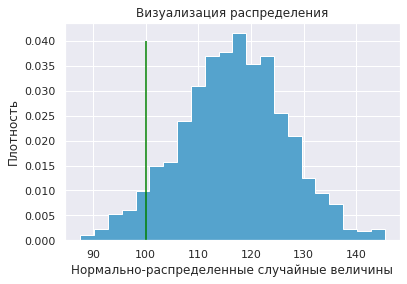

In [73]:
p = 0.1
n = 1168
    
mu = n * p
sigma = sqrt(n * p * (1 - p))

distr = st.norm(mu, sigma) 

result = distr.cdf(100)
print(result)

plt.hist(distr.rvs(1000), density=True, bins='auto', histtype='stepfilled');
plt.vlines(x=100, ymin=0, ymax=0.04, color='green')
plt.title("Визуализация распределения")
plt.xlabel("Нормально-распределенные случайные величины")
plt.ylabel("Плотность")

**Вывод**

Чтобы по итогам акции подписку продлили не менее 100 человек, а вероятность не выполнить план составляла 5% при вероятности успеха 0.1, необходимо отправить 1168 промокодов.

---
### Задание №2

**Условие** 

Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40% получивших клиентов. 

Отдел планирует разослать 1 млн уведомлений. 
С помощью аппроксимации постройте примерный график распределения и оцените вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

**Решение** 

$p = 0,4$ - вероятность того, что уведомление будет открыто

$n = 1000000$ - количество уведомлений

Аппроксимируем биномиальное распределение нормальным с помощью метода метода `cdf()` и вычислим вероятность того, что уведомление откроют менее 399 500 пользователей.

Для аппроксимации распределения вычислим показатели `mu` и `sigma` перед применением метода. Дополнительно построим график распределения для визуализации полученных результатов.

0.15371708296369768


Text(0, 0.5, 'Плотность')

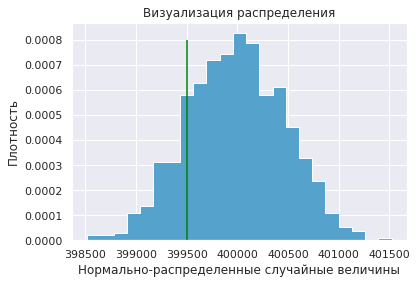

In [74]:
p = 0.4
n = 1000000
    
mu = n * p
sigma = sqrt(n * p * (1 - p))

distr = st.norm(mu, sigma) 

result = distr.cdf(399500)
print(result)

plt.hist(distr.rvs(1000), density=True, bins='auto', histtype='stepfilled');
plt.vlines(x=399500, ymin=0, ymax=0.0008, color='green')
plt.title("Визуализация распределения")
plt.xlabel("Нормально-распределенные случайные величины")
plt.ylabel("Плотность")

**Вывод**

Вероятность того, что push-уведомление откроют менее 399 500 пользователей равна 15%. 

--- 

## Общий вывод

### Изучение данных

Перед проведением исследования данные были изучены:

- импортированы соответствующие библиотеки;
- считаны три датасета с данными о пользователях, их поездках и подписках, которые были сохранены в переменные `users`, `rides`, `subscriptions`;
- изучена общая информация о полученных датафреймах;
- изучены имеющиеся пропуски в данных, тип данных, именование столбцов

### Предобработка данных

В ходе изучения датафреймов была выявлена необходимость предобработки данных.

---

#### Изменение типа данных

Определены столбцы, в которых стоит изменить тип данных для проведения дальнейшего анализа:

- столбец `date` в датафрейме `rides` переведён из типа "object" в "datetime" для определения месяца поездки.

---

#### Поиск и заполнение пропущенных значений

Гистограммы `msno` показали отсутствие пропущенных значений, данные в датафреймах представлены полностью.

---

#### Обработка дубликатов

Найдены и удалены явные дубликаты в датафрейме `users`.

Неявных совпадений строк в датафреймах не выявлено.

---

#### Аномалии в данных

Столбцы `distance` и `duration` датафрейма `rides` были проверены на наличие аномалий и выбросов с помощью метода `describe()`. 
Данные в столбцах распределены корректно, отсутствуют отрицательные значения и аномальные выбросы.

---

#### Добавление новых столбцов с заданными параметрами

В датафрейм `rides` добавлен новый столбец с номером месяца поездки на основе столбца `date`.

---

### Исследовательский анализ данных

Для проведения исследовательского анализа были созданы сводные таблицы и построены графики для наглядного отображения результатов. 

---

#### Частота встречаемости городов 

Частота встречаемости городов в выборке изучена по датафрейму `users`, для отображения результатов построена линейчатая гистограмма.

*Вывод:*

Наиболее часто в выборке встречается город Пятигорск - 219 пользователей, реже всего встречается город Москва - 168 пользователей.

---

#### Соотношение пользователей с подпиской и без

Найдена долю каждой категории пользователей (с подпиской и без) от общего числа клиентов, для отображения результатов построена круговая диаграмма.

*Вывод:*

Распределение пользователей в выборке практически равномерное: 54% клиентов без платной подписки и 46% клиентов имеют платную подписку.

---    
    
#### Возраст пользователей

Возраст пользователей изучен по датафрейму `users`, для отображения результатов построена гистограмма распределения.

*Вывод:*

Получено нормальное распределение:

- самой многочисленной категорией в выборке являются пользователи от 20 до 30 лет.
- самой малочисленной - клиенты в возрасте до 15 лет и от 35 лет и выше.

---
    
#### Расстояние, которое пользователь преодолел за одну поездку

Расстояние, которое пользователь преодолел за одну поездку, изучено с помощью столбца `distance` датафрейма `rides`, для отображения результатов построена гистограмма распределения.


*Вывод:*

Чаще всего пользователи берут самокат на средние расстояния от 2 до 4 км, реже всего на длинные дистанции от 5 км.

Также на графике заметен небольшой пик поездок с расстоянием до 1км.

---

#### Продолжительность поездок

Продолжительность поездок пользователей изучена с помощью столбца `duration` датафрейма `rides`, для отображения результатов построена гистограмма распределения.

*Вывод:*

Самая частая продолжительность поездки - от 10 до 25 минут, что коррелируется с самым частым расстоянием поездок.

Наименее частые поездки длятся до 5 минут и превышают 30 минут.

Дополнительно был выявлен и исследован небольшой пик при 0, в который вошли отменённые поездки.

---

### Объединение данных

Для проведения дальнейшего исследования датафреймы `users`, `rides` и `subscriptions` объединены и записаны в переменную `full`.

В итоговый датафрейм `full` попали все 18068 строк самой большой таблицы `rides`, объединение прошло корректно, данные не потеряны.

---

#### Создание датафреймов

Из полученной таблицы `full` созданы два дополнительных датафрейма:

- `free` - с данными о пользователях без подписки;
- `ultra` - с данными о пользователях с подпиской

Датафреймы созданы корректно, в каждом собраны данные одной из категорий пользователей: с подпиской и без подписки.
Количество поездок пользователей без подписки почти в два раза превышает количество поездок пользователей с подпиской.

---

#### Визуализация данных

Визуализираны данные о расстоянии и времени поездок для пользователей обеих категорий, для отображения результатов построены гистограммы.

*Вывод:*

Получены нормальные распределения расстояния поездок пользователей с подпиской и без.

График показывает, что среди пользователей с подпиской преобладает расстояние поездки в 3км, а среди пользователей без подписки - 2.5км.

Также можно отметить, что пользователи без подписки чаще ездят на длительные расстояния от 5км и на короткие расстояния до 1км.

Получены нормальные распределения расстояния поездок пользователей с подпиской и без.

График показывает, что среди пользователей с подпиской преобладает длительность поездки от 13 до 18 минут, а среди пользователей без подписки - от 15 до 20 минут.

Дополнительно подтверждается предположение о том, что поездки, продолжительностью до 1 минуты отменены по причине неуспеха оплаты старта поездки. График показывает, что в данный пик вошли только пользователи без подписки.

---

*Вывод:*

Для дальнейшей работы с данными исходные датафреймы  `users`, `rides` и `subscriptions` были объединенины в общую таблицу `full`.

После чего `full` была разделена на два дополнительных датафрейма `free` и `ultra`, содержащих данные о пользователях без подписки и пользователях с подпиской. 

Дополнительно были визуализированы данные о расстоянии и времени поездок для пользователей обеих категорий.

---

### Подсчёт выручки


#### Агрегирование данных о поездках

С помощью датафрейма `full` создана таблицу с агрегированными данными о суммарном расстоянии, количестве поездок и суммарном времени поездок для каждого пользователя за каждый месяц.

---

#### Агрегирование выручки

В полученный агрегированный датафрейм добалены данные о помесячной выручке, которую принёс каждый пользователь.

*Вывод:*

На данном этапе исследования был получен датафрейм `rides_grouped` с агрегированными помесячно данными: 
- суммарное расстояние;
- суммарная продолжительность;
- количество поездок;
- выручка, которую принёс каждый пользователь.

---

### Проверка гипотез

#### Гипотеза №1

Необходимо понять, тратят ли пользователи с подпиской больше времени на поездки, чем пользователи без подписки. Если да, то пользователи с подпиской могут быть «выгоднее» для компании.

Гипотеза проверена по выборочным средним на датафреймах `free` и `ultra`, где собраны данные о пользователях с подпиской и без.

Для проверки использован метод `t-тест`.

*Вывод:*

Полученное значение `p-value` равно $1.2804098316645618⋅10^{-34}$, а значит, вероятность получения наблюдаемых результатов при условии, что нулевая гипотеза верна, очень мала.

Нулевая гипотеза отвергается в пользу альтернативной и можно заключить, что среднее значение совокупности "время поездки пользователей с подпиской" **больше** среднего значения совокупности "время поездки пользователей без подписки".

---

#### Гипотеза №2

Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? Проверьте гипотезу и сделайте выводы.

Гипотеза проверена по выборочному среднему датафрейма `ultra`, где собраны данные о пользователях с подпиской, которое сравнивалось с заданным числом в 3130 метров.

Для проверки использован односторонний тест и метод `ttest_1samp()`, где в качестве аргумента укажем `alternative`=`'greater'`.

*Вывод:*

Нулевую гипотезу не получилось отвергнуть в пользу альтернативной. 

Полученное значение `p-value` в $0.92$ выше заданного уровня статистической значимости - это означает, что наблюдаемое значение вероятно при такой нулевой гипотезе.

Ожидание, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, превышает 3130 метров **не подтвердилось**.

---

#### Гипотеза №3

Необходимо проверить гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.

Гипотеза проверена по выборочным средним сгруппированных данных о помесячной выручке пользователей с подпиской и без.

Для проверки использован метод `st.ttest_ind`.

Данные о помесячной выручке пользователей с подпиской и без сгруппированы дополнительно.

*Вывод:*

Полученное значение `p-value` равно $8.874140893976874⋅10^{-40}$, а значит, вероятность получения наблюдаемых результатов при условии, что нулевая гипотеза верна, очень мала.

Нулевая гипотеза отвергается в пользу альтернативной и можно заключить, что помесячная выручка от пользователей с подпиской по месяцам **выше**, чем выручка от пользователей без подписки.

---

#### Гипотеза №4 

Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось.

Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него.

Какой тест вам понадобился бы для проверки этой гипотезы?

*Вывод:*

Необходимо проверить, уменьшилось ли количество обращений в поддержку после обновления серверов. Нам предоставили данные о кол-ве обращений каждого конкретного пользователя до и после изменений.

В этом случае исследуем одну генеральную совокупность, с которой произошли некоторые изменения. Для этого стоит использовать гипотезу о равенстве средних для зависимых (парных) выборок.

Для проверки гипотезы воспользуемся методом `scipy.stats.ttest_rel()` и передадим ему параметры: наборы данных до и после обновления серверов и `alternative` = `'greater'`.

Для формулирования вывода используем полученное значение `p-value`: если оно превышает уровень статистической значимости, то мы не сможем отвергнуть нулевую гипотезу в пользу альтернативной.

---

### Распределения

#### Задание №1

Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку.

То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж.

Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10 % пользователей.

Выясните, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %. Подберите параметры распределения, описывающего эту ситуацию, постройте график распределения и сформулируйте ответ на вопрос о количестве промокодов.

Аппроксимируем биномиальное распределение нормальным с помощью метода метода `cdf()` и подберём подходящее значение параметра $N$ для заданного параметра $p=0.1$, чтобы вероятность не выполнить план была примерно 5%.

Для аппроксимации распределения вычислим показатели `mu` и `sigma` перед применением метода.


*Вывод:*

Чтобы по итогам акции подписку продлили не менее 100 человек, а вероятность не выполнить план составляла 5% при вероятности успеха 0.1, необходимо отправить 1168 промокодов.

---

#### Задание №2

Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40% получивших клиентов.

Отдел планирует разослать 1 млн уведомлений. С помощью аппроксимации постройте примерный график распределения и оцените вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

Аппроксимируем биномиальное распределение нормальным с помощью метода метода `cdf()` и вычислим вероятность того, что уведомление откроют менее 399 500 пользователей.

Для аппроксимации распределения вычислим показатели `mu` и `sigma` перед применением метода.

*Вывод:*

Вероятность того, что push-уведомление откроют менее 399 500 пользователей равна 15%.

### Заключение

Для проведения исследования были получены данные о некоторых пользователях популярного сервиса аренды самокатов GoFast из нескольких городов: сведения об их поездках и подписках. 

В ходе исследования данные были изучены и подготовлены к проверке гипотез, которые могут помочь бизнесу вырасти.

- **Вывод 1**

Для формирования рекомендаций проверена гипотеза о том, тратят ли пользователи с подпиской больше времени на поездки, чем пользователи без подписки.

По итогам проверки гипотезы можно заключить, что пользователи с подпиской действительно тратят больше времени на поездки, а значит, сервису стоит постараться привлечь больше своих пользователей к покупке подписки.

- **Вывод 2**

С точки зрения износа самоката, оптимальное расстояние одной поездки - 3130 метров.

Проверена гипотеза о том, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, превышает 3130 метров. 

Ожидание, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, превышает 3130 метров не подтвердилось. Пользователи с подпиской используют самокаты оптимально с точки зрения износа.

- **Вывод 3**

Проверена гипотеза о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.

Результаты показали, что помесячная выручка от пользователей с подпиской по месяцам действительно выше, чем выручка от пользователей без подписки. 

---

**Итог:**

Для увеличения выручки и роста бизнеса сервису стоит постараться привлечь больше своих пользователей к покупке подписки: помимо стоимости самой подписки пользователи данной категории тратят больше времени на поездки, а значит, выручка от поездок также увеличивается.

Дополнительно пользователи с подпиской используют самокаты достаточно оптимально с точки зрения износа. Увеличение числа пользователей с подпиской поможет продлить срок службы самокатов и сократить расходы на замену и ремонт оборудования.